In [1]:
from licks import *

# Magics
%load_ext autoreload
%autoreload 2

# Load behavioral data

In [2]:
df_behavior = pd.read_csv(r'C:\Users\Usuario\PycharmProjects\glue_sessions\2AFC_2\333.csv', low_memory=False)

# Filter data

In [3]:
# Filters for groups 1-3
df_behavior = df_behavior[df_behavior.P > 0].reset_index(drop=True)

# Filters for groups 4-5 (otherwise bump in lick rate before stimulus onset)
# df_behavior = df_behavior[df_behavior.Task == 'FD'].reset_index(drop=True)
# df_behavior = df_behavior[df_behavior.Delay == 0.5].reset_index(drop=True)

# Add lick data to the DataFrame

In [4]:
old_columns = list(df_behavior.columns)  # Save old columns for comparison later
df_behavior = add_lick_data(df_behavior)
new_columns = list(df_behavior.columns)
new_columns = [col for col in new_columns if col not in old_columns]
print(new_columns)

0.23% of trials corrupted due to licks outside response window
['LicksLeft', 'LicksRight', 'nLicksLeft', 'nLicksRight', 'ILI_Left', 'ILI_Right', 'RT']


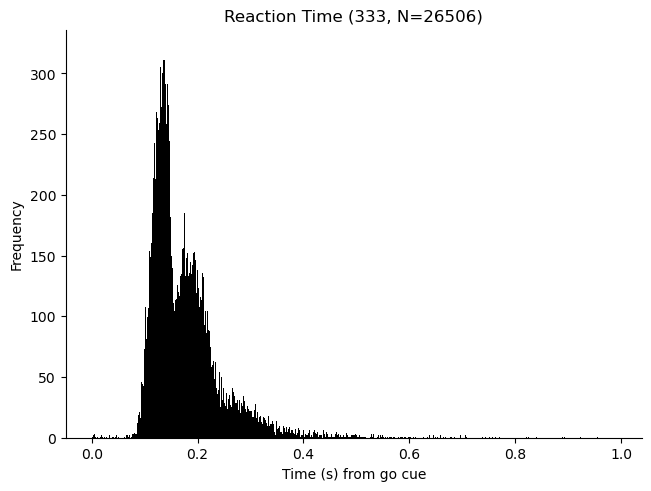

In [5]:
plot_rts(df_behavior)

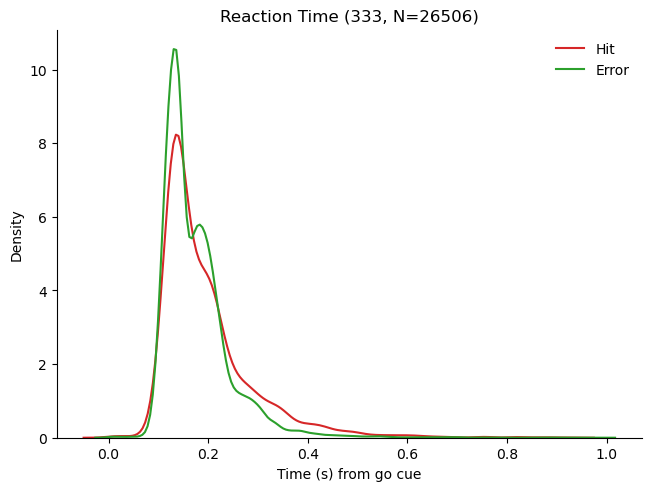

In [6]:
plot_rts_split(df_behavior, kind='kde')

   abs_ILD        RT
0      0.0  0.180495
1      2.0  0.181170
2      4.0  0.180194
3      8.0  0.183126
4     70.0  0.175353


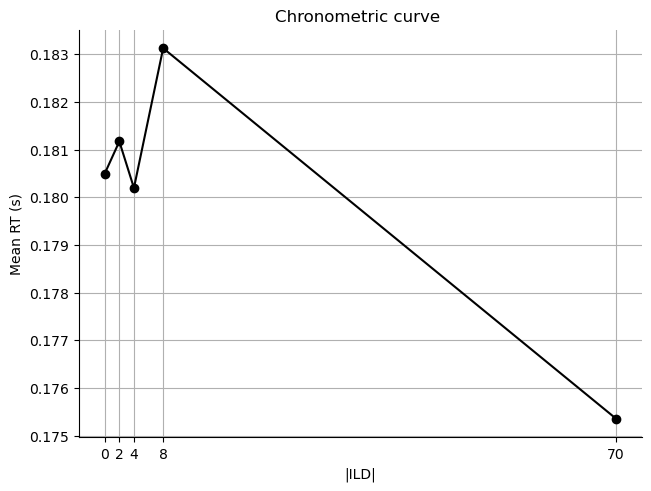

In [7]:
plot_chrono_curve(df_behavior)

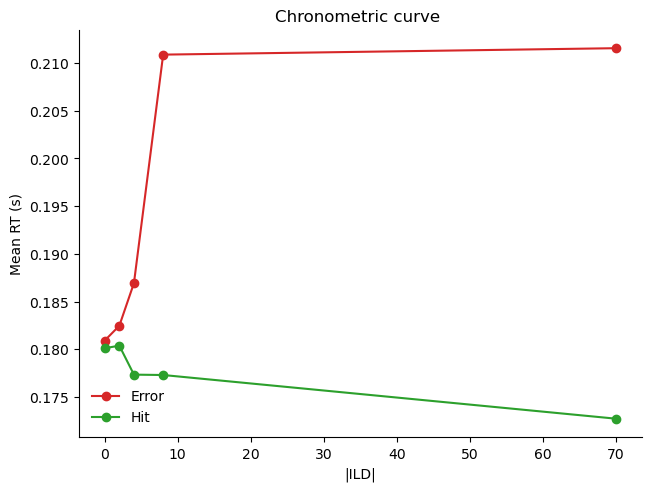

In [8]:
plot_chrono_curve_split(df_behavior, split='outcome', absolute=True)

In [9]:
# # Plot licks PSTH
# bins, left_psth = compute_psth(licks_left, time_win=[-1, 3], bin_size=0.1)
# bins, right_psth = compute_psth(licks_right, time_win=[-1, 3], bin_size=0.1)
# bins = bins[:-1]  # Remove the last bin edge to match the histogram length
# plot_licks_psth(bins, licks_left, licks_right)